In [1]:
from torch.quantization import quantize_dynamic
from sentence_transformers import SentenceTransformer, util, InputExample, losses
import pandas as pd

In [2]:
from sentence_transformers import SentenceTransformer, util
import numpy as np
from sklearn.cluster import AgglomerativeClustering
import seaborn as sns
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from sklearn.cluster import MiniBatchKMeans
import gensim
from gensim import corpora
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, silhouette_score
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /Users/lea/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
# Load SBERT model
model = SentenceTransformer('paraphrase-MiniLM-L3-v2')

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/4.04k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/314 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

1_Pooling/config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
import nltk

nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
# Function to read and preprocess text data
def read_and_preprocess(file_path):
    with open(file_path, 'r', encoding='utf-8') as file:
        text = file.read()
        text=text.replace('\n','')
        split_text=text.split("See also",-1) # remove the references
        text=split_text[0]
    sentences = nltk.sent_tokenize(text)  # Tokenize into sentences
    return [sentence.strip() for sentence in sentences if sentence.strip()]

# Load datasets
history_sentences = read_and_preprocess('/content/drive/MyDrive/history_timeline/1940s.txt')
movies_sentences = read_and_preprocess('/content/drive/MyDrive/decade_summaries/summaries_decade_1940.txt')

print(len(history_sentences))
history_sentences = history_sentences[:1000]  # Use the first 500 sentences as a test
movies_sentences = movies_sentences[:1000]   # Use the first 200 sentences as a test

71


In [ ]:
# Encode sentences into embeddings
history_embeddings = model.encode(history_sentences, batch_size=32, convert_to_tensor=True)
movies_embeddings = model.encode(movies_sentences, batch_size=32, convert_to_tensor=True)
best_clust_nums=np.zeros(20)


In [ ]:
for k in np.arange(20):
  num_clusters = np.arange(1,20,1)+1
  sil_scores= np.zeros(len(num_clusters))
  for i in np.arange(len(num_clusters)):
    cluster_model = MiniBatchKMeans(n_clusters=num_clusters[i])
    cluster_labels = cluster_model.fit_predict(history_embeddings.cpu().numpy())
    sil_score = silhouette_score(history_embeddings.cpu().numpy(), cluster_labels)
    sil_scores[i]= sil_score
  best_clust_num=num_clusters[np.argmax(sil_scores)] # number of clusters with the best silhouette score
  best_clust_nums[k]=best_clust_num
best_clust_nums=best_clust_nums.astype(int)
counts=np.bincount(best_clust_nums)
most_freq=np.argmax(counts) # most frequent best cluster number over the repetitions
num_clusters_final=most_freq

In [ ]:
print(len(movies_sentences))
print(history_embeddings.shape)
print(movies_embeddings.shape)
# Compute pairwise similarity matrix
similarity_matrix = util.pytorch_cos_sim(history_embeddings, movies_embeddings).cpu().numpy()

# Perform clustering on history dataset
cluster_model = MiniBatchKMeans(n_clusters=num_clusters_final)
history_clusters = cluster_model.fit_predict(history_embeddings.cpu().numpy())

1000
torch.Size([71, 384])
torch.Size([1000, 384])


In [ ]:
# Cluster sentences from history into semantic fields
clustered_history = {i: [] for i in range(max(history_clusters) + 1)}
for idx, cluster_id in enumerate(history_clusters):
    clustered_history[cluster_id].append(history_sentences[idx])

In [ ]:
for idx,value in clustered_history.items():
  print(value)

['Georgy Zhukov, SovietUnion Field Marshal wholed the Red Army duringthe Battle of Berlin.', 'Erwin Rommel, GermanField Marshal who ledthe Nazis during theNorth African Campaign.', 'Field Marshal Erwin Rommel Reichsmarschall Hermann Göring Field Marshal Erich von Manstein Field Marshal Gerd von Rundstedt Field Marshal Carl Gustaf Emil Mannerheim Marshal Ion Antonescu General Hideki Tōjō General Kuniaki Koiso Field Marshal Hajime Sugiyama Fleet Admiral  Isoroku Yamamoto Fleet Admiral  Osami Nagano Field Marshal Georgy Zhukov Field Marshal Ivan Konev General Dwight D. Eisenhower General George Marshall General Douglas MacArthur General Omar Bradley General George S. Patton Fleet Admiral  Chester W .', "King Field Marshal Harold Alexander Field Marshal Bernard Montgomery Général d'Armée  Jean de Lattre de Tassigny Brigadier general  Charles de Gaulle General Henri WinkelmanPeopleMilitary leaders General Bernhard of Lippe-BiesterfeldMohandas Gandhiduring the 1940s Raoul Wallenberg, c.1944 

In [ ]:
topic_text=''
for i in clustered_history[0]:
  topic_text+=i
print(topic_text)

Georgy Zhukov, SovietUnion Field Marshal wholed the Red Army duringthe Battle of Berlin.Erwin Rommel, GermanField Marshal who ledthe Nazis during theNorth African Campaign.Field Marshal Erwin Rommel Reichsmarschall Hermann Göring Field Marshal Erich von Manstein Field Marshal Gerd von Rundstedt Field Marshal Carl Gustaf Emil Mannerheim Marshal Ion Antonescu General Hideki Tōjō General Kuniaki Koiso Field Marshal Hajime Sugiyama Fleet Admiral  Isoroku Yamamoto Fleet Admiral  Osami Nagano Field Marshal Georgy Zhukov Field Marshal Ivan Konev General Dwight D. Eisenhower General George Marshall General Douglas MacArthur General Omar Bradley General George S. Patton Fleet Admiral  Chester W .King Field Marshal Harold Alexander Field Marshal Bernard Montgomery Général d'Armée  Jean de Lattre de Tassigny Brigadier general  Charles de Gaulle General Henri WinkelmanPeopleMilitary leaders General Bernhard of Lippe-BiesterfeldMohandas Gandhiduring the 1940s Raoul Wallenberg, c.1944 Muhammed Ali J

In [ ]:
topic_text=''
for i in clustered_history[1]:
  topic_text+=i
print(topic_text)

Above title bar: events during World War II (1939–1945): From left to right: Troops in an LCVP landingcraft approaching Omaha Beach on D-Day; Adolf Hitlervisits Paris, soon after the Battle of France; TheHolocaust occurs as Nazi Germany carries out aprogramme of systematic state-sponsored genocide,during which approximately six million European Jewsare killed; The Japanese attack on the Americannaval base of Pearl Harbor launches the UnitedStates into the war; An Observer Corps spotter scansthe skies of London during the Battle of Britain andThe Blitz; The creation of the Manhattan Project leadsto the atomic bombings of Hiroshima and Nagasaki,the first uses of nuclear weapons, which kill over aquarter million people and lead to the Japanesesurrender; Japanese Foreign Minister MamoruShigemitsu signs the Instrument of Surrender onbehalf of the Japanese Government, on boardUSS Missouri, effectively ending the war.Below title bar: events after World War II: From left toright: The Declarati

In [ ]:
texts = clustered_history[0]

# Preprocess the text
stop_words = set(stopwords.words('english'))
processed_texts = []

for text in texts:
    tokens = word_tokenize(text.lower())
    filtered_tokens = [word for word in tokens if (len(word)>1) and (word not in stop_words) and (word.isalnum())]
    processed_texts.append(filtered_tokens)

# Create a dictionary and corpus
dictionary = corpora.Dictionary(processed_texts)
corpus = [dictionary.doc2bow(text) for text in processed_texts]

# Apply LDA model
lda_model = gensim.models.LdaMulticore(corpus, num_topics=2, id2word=dictionary, passes=10)

# Print the topics
for idx, topic in lda_model.print_topics():
    print(f"Topic {idx}: {topic}")

Topic 0: 0.029*"erwin" + 0.029*"rommel" + 0.029*"thenorth" + 0.029*"campaign" + 0.029*"african" + 0.029*"nazis" + 0.029*"ledthe" + 0.029*"germanfield" + 0.029*"marshal" + 0.011*"general"
Topic 1: 0.073*"marshal" + 0.066*"field" + 0.066*"general" + 0.022*"de" + 0.022*"admiral" + 0.022*"fleet" + 0.016*"georgy" + 0.016*"zhukov" + 0.016*"george" + 0.016*"von"


In [ ]:
# Compute average similarity per cluster
topic_similarities = []
cluster_similarities = {i: [] for i in np.arange(len(clustered_history))+1}
print(cluster_similarities)
for cluster_id, sentences in clustered_history.items():
    cluster_emb = model.encode(sentences, convert_to_tensor=True).mean(dim=0)  # Average embedding for the cluster
    similarities = util.pytorch_cos_sim(cluster_emb, movies_embeddings).cpu().numpy()
    similarities_list = similarities[0].tolist()
    cluster_similarities[cluster_id+1]=similarities_list  # Store similarities
    topic_similarities.append(similarities.max())  # Store max similarity for the bar plot

# Save bar plot data (Maximum similarity per cluster)
bar_plot_data = pd.DataFrame({
    'Cluster ID': list(clustered_history.keys()),
    'Max Similarity': topic_similarities
})
bar_plot_data.to_csv('bar_plot_data.csv', index=False)

{1: [], 2: [], 3: [], 4: [], 5: [], 6: [], 7: [], 8: [], 9: [], 10: [], 11: [], 12: [], 13: [], 14: [], 15: [], 16: [], 17: [], 18: [], 19: [], 20: []}
[-0.024318333715200424, 0.044111866503953934, -0.12534622848033905, -0.09864996373653412, -0.12335105240345001, -0.14883482456207275, -0.07606600970029831, 0.018706418573856354, 0.027561005204916, -0.09452058374881744, -0.04878639057278633, -0.1325705349445343, -0.05786415562033653, -0.08027385920286179, -0.04219324141740799, -0.007946200668811798, 0.002317287027835846, -0.07876203209161758, 0.05761311575770378, 0.0028509944677352905, -0.07004112005233765, -0.03649158030748367, -0.13910993933677673, -0.0844721645116806, -0.09060603380203247, -3.8471072912216187e-05, -0.11072173714637756, -0.09633617848157883, -0.029329419136047363, -0.014295872300863266, 0.0032730121165513992, 0.02610136568546295, 0.07435018569231033, 0.05778992176055908, 0.10290026664733887, 0.021824870258569717, -0.018907025456428528, 0.002348467707633972, 0.068286642

In [ ]:
# Save heatmap data (similarity matrix)


heatmap_data = pd.DataFrame(
    cluster_similarities)

heatmap_data.index=[f"Movie {i+1}" for i in range(len(movies_sentences))]
heatmap_data.columns=[f"Cluster {i}" for i in range(len(clustered_history))]
heatmap_data.to_csv('heatmap_data.csv')

heatmap_data.head()

NameError: name 'cluster_similarities' is not defined

<ipython-input-70-67c1354105c9>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bar_plot_data['Cluster ID'], y=bar_plot_data['Max Similarity'], palette="viridis")


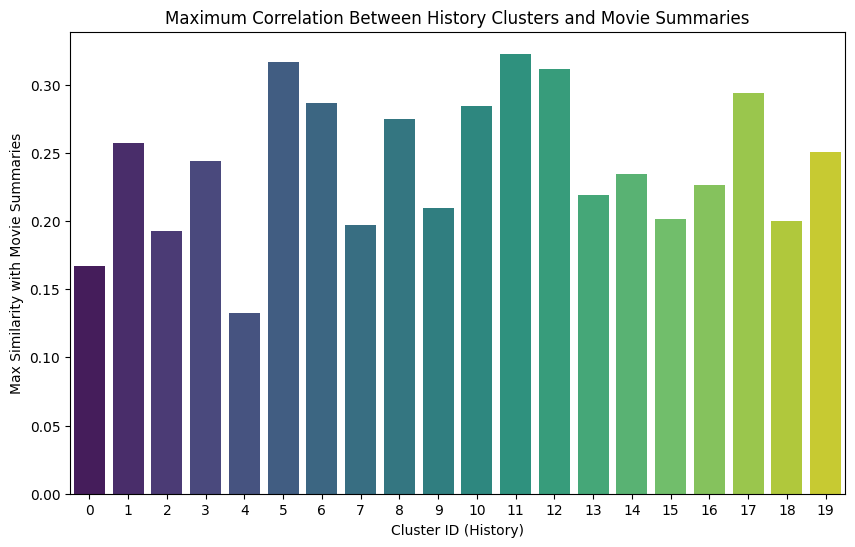

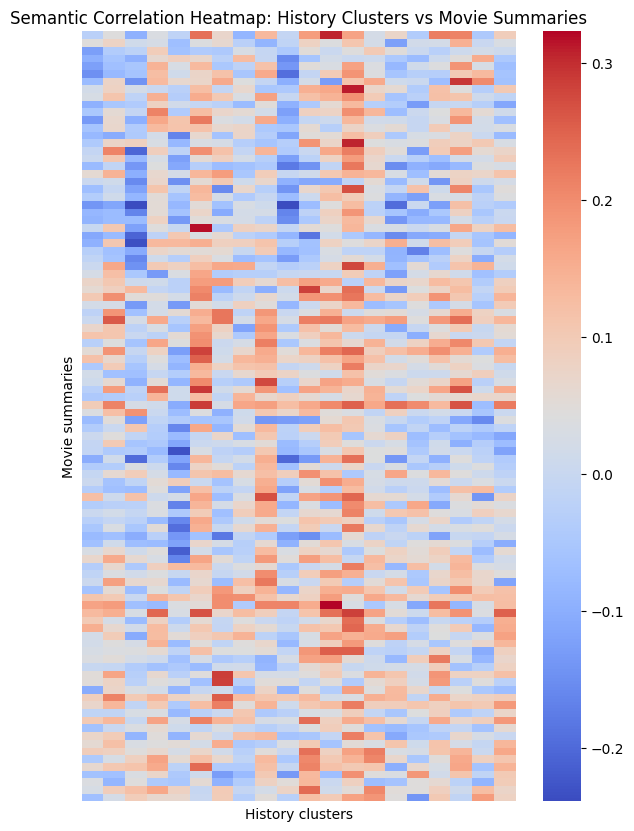

In [ ]:
# Visualization: Bar Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=bar_plot_data['Cluster ID'], y=bar_plot_data['Max Similarity'], palette="viridis")
plt.xlabel('Cluster ID (History)')
plt.ylabel('Max Similarity with Movie Summaries')
plt.title('Maximum Correlation Between History Clusters and Movie Summaries')
plt.show()

# Visualization: Heatmap
plt.figure(figsize=(7, 10))
sns.heatmap(heatmap_data, annot=False, fmt=".2f", cmap="coolwarm")
plt.title('Semantic Correlation Heatmap: History Clusters vs Movie Summaries')
plt.xticks([])
plt.yticks([])
plt.xlabel('History clusters')
plt.ylabel('Movie summaries')
plt.show()

# Clustering on the summaries

In [4]:
# Function to read and preprocess text data
def read_and_preprocess_sum(file_path):
    with open(file_path, 'r', encoding='utf-8') as file:
        text = file.read()
        text = text.replace('\n', ' ')  # Remplace les sauts de ligne par des espaces
    
     # Tokenize into sentences
    sentences = nltk.sent_tokenize(text)
    
    return [sentence.strip() for sentence in sentences if sentence.strip()]

file_path = 'src/data/Summaries_decades/summaries_decade_1940.txt'
movies_sentences = read_and_preprocess_sum(file_path)

print(f"Nombre total de phrases : {len(movies_sentences)}")
print("Exemple de phrases :", movies_sentences[:5])

Nombre total de phrases : 16392
Exemple de phrases : ['Hayworth stars as the Muse Terpsichore who is annoyed that popular Broadway producer Danny Miller  is putting on a play which portrays the Muses as man-crazy tarts fighting for the attention of a pair of Air Force pilots who crashed on Mount Parnassus .', 'She asks permission from Mr. Jordan to go to Earth and fix the play.', 'Jordan agrees and sends Messenger 7013  to keep an eye on her.', 'Terpsichore uses the name Kitty Pendleton and quickly gets an agent, Max Corkle , and a part in the show.', 'As the play is being rehearsed, Kitty takes every chance she gets to tell Danny that his depictions of the Muses are wrong.']


In [5]:
# Étape 1 : Encode les phrases de 'movies_sentences' en embeddings
movies_embeddings = model.encode(movies_sentences, batch_size=32, convert_to_tensor=True)

# Paramètres
num_repetitions = 20  # Nombre de répétitions pour stabiliser le choix du nombre optimal de clusters
max_clusters = 20  # Nombre maximal de clusters à tester
best_clust_nums = np.zeros(num_repetitions, dtype=int)  # Stockage des meilleurs nombres de clusters

# Étape 2 : Recherche du meilleur nombre de clusters pour 'movies_sentences'
for k in range(num_repetitions):
    sil_scores = np.zeros(max_clusters - 1)  # Stockage des scores de silhouette pour chaque valeur de cluster
    for n_clusters in range(2, max_clusters + 1):  # Tester de 2 à max_clusters
        cluster_model = MiniBatchKMeans(n_clusters=n_clusters, random_state=k)
        cluster_labels = cluster_model.fit_predict(movies_embeddings.cpu().numpy())
        
        # Calculer le score de silhouette
        sil_score = silhouette_score(movies_embeddings.cpu().numpy(), cluster_labels)
        sil_scores[n_clusters - 2] = sil_score  # Stocker le score pour n_clusters
        
    # Trouver le nombre de clusters avec le meilleur score de silhouette
    best_clust_nums[k] = np.argmax(sil_scores) + 2  # Ajuster l'indice pour correspondre à n_clusters

# Étape 3 : Déterminer le nombre de clusters le plus fréquent
counts = np.bincount(best_clust_nums)
num_clusters_final = np.argmax(counts)  # Nombre de clusters le plus fréquent

# Résultat
print(f"Nombre optimal de clusters pour 'movies_sentences' : {num_clusters_final}")

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
/Users/lea/opt/anaconda3/envs/ada2/lib/python3.11/site-packages/threadpoolctl.py:1214: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


KeyboardInterrupt: 